# CS5812 Predictive Data Analysis
## Smart Meters in London Daily Energy Consumption Prediction

**Research Question:**  
How accurately can we predict a household's daily electricity consumption (kWh) from weather, calendar, and recent consumption history using ML and DL models?

**Target variable:** `energy_sum`  total daily household consumption (kWh)  
**Dataset:** [Smart Meters in London](https://www.kaggle.com/datasets/jeanmidev/smart-meters-in-london)


---
## 1. Load Data

In [1]:
import pandas as pd
import numpy as np

SEED = 50
np.random.seed(SEED)

daily = pd.read_csv('data/daily_dataset.csv')
print(f"Daily rows: {len(daily):,}")
daily.describe()

Daily rows: 3,510,433


,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
count,3.510403e+06,3.510403e+06,3.510403e+06,3.510433e+06,3.499102e+06,3.510403e+06,3.510403e+06
mean,1.587395e-01,2.117305e-01,8.345210e-01,4.780364e+01,1.726673e-01,1.012414e+01,5.962578e-02
std,1.701865e-01,1.908460e-01,6.683156e-01,2.810982e+00,1.531208e-01,9.128793e+00,8.701312e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.700000e-02,9.808333e-02,3.460000e-01,4.800000e+01,6.911626e-02,4.682000e+00,2.000000e-02
50%,1.145000e-01,1.632917e-01,6.880000e-01,4.800000e+01,1.327910e-01,7.815000e+00,3.900000e-02
75%,1.910000e-01,2.624583e-01,1.128000e+00,4.800000e+01,2.293124e-01,1.256900e+01,7.100000e-02
max,6.970500e+00,6.928250e+00,1.076100e+01,4.800000e+01,4.024569e+00,3.325560e+02,6.524000e+00


---
## 2. Feature Engineering

In [2]:
# Weather data
weather = pd.read_csv('data/weather_daily_darksky.csv')
weather['date'] = pd.to_datetime(weather['time'])
daily['date']   = pd.to_datetime(daily['day'])
daily = daily.merge(weather, on='date', how='inner')
print(f"After weather merge: {len(daily):,}")
daily.describe()

After weather merge: 1,546,951


,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,date,temperatureMax,windBearing,...,visibility,humidity,apparentTemperatureLow,apparentTemperatureMax,uvIndex,temperatureLow,temperatureMin,temperatureHigh,apparentTemperatureMin,moonPhase
count,1.546923e+06,1.546923e+06,1.546923e+06,1.546951e+06,1.539619e+06,1.546923e+06,1.546923e+06,1546951,1.546951e+06,1.546951e+06,...,1.546951e+06,1.546951e+06,1.546951e+06,1.546951e+06,1.541852e+06,1.546951e+06,1.546951e+06,1.546951e+06,1.546951e+06,1.546951e+06
mean,1.858810e-01,2.470752e-01,9.401058e-01,4.774811e+01,2.013212e-01,1.180390e+01,6.522719e-02,2013-05-20 21:29:03.965516,8.615396e+00,1.970440e+02,...,1.069729e+01,8.220597e-01,1.547199e+00,7.030414e+00,1.088945e+00,4.205098e+00,3.790446e+00,8.370554e+00,1.107433e+00,5.034048e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2011-11-23 00:00:00,-6.000000e-02,0.000000e+00,...,1.930000e+00,5.900000e-01,-8.880000e+00,-4.110000e+00,0.000000e+00,-5.640000e+00,-5.640000e+00,-8.100000e-01,-8.880000e+00,0.000000e+00
25%,7.350000e-02,1.111458e-01,4.010000e-01,4.800000e+01,8.279748e-02,5.298000e+00,2.000000e-02,2012-12-25 00:00:00,6.620000e+00,1.470000e+02,...,9.660000e+00,7.800000e-01,-1.270000e+00,4.060000e+00,1.000000e+00,1.970000e+00,1.630000e+00,6.420000e+00,-1.300000e+00,2.700000e-01
50%,1.295000e-01,1.865208e-01,7.850000e-01,4.800000e+01,1.553941e-01,8.923000e+00,4.000000e-02,2013-03-05 00:00:00,9.210000e+00,2.170000e+02,...,1.149000e+01,8.300000e-01,1.420000e+00,7.080000e+00,1.000000e+00,4.200000e+00,3.640000e+00,9.030000e+00,1.160000e+00,5.100000e-01
75%,2.205000e-01,3.050625e-01,1.257000e+00,4.800000e+01,2.651668e-01,1.460500e+01,7.300000e-02,2013-12-14 00:00:00,1.082000e+01,2.510000e+02,...,1.267000e+01,8.800000e-01,4.280000e+00,1.082000e+01,1.000000e+00,6.750000e+00,6.300000e+00,1.033000e+01,3.420000e+00,7.400000e-01
max,6.970500e+00,6.928250e+00,1.076100e+01,4.800000e+01,4.024569e+00,3.325560e+02,6.394000e+00,2014-02-28 00:00:00,1.948000e+01,3.590000e+02,...,1.408000e+01,9.700000e-01,1.234000e+01,1.948000e+01,3.000000e+00,1.234000e+01,1.161000e+01,1.948000e+01,1.161000e+01,9.900000e-01
std,2.081955e-01,2.283343e-01,7.420927e-01,3.299826e+00,1.767998e-01,1.091426e+01,1.075533e-01,NaN,3.366384e+00,8.619966e+01,...,2.566502e+00,7.375060e-02,3.868181e+00,4.524550e+00,5.079463e-01,3.307345e+00,3.104225e+00,3.360066e+00,3.578463e+00,2.818624e-01


In [3]:
# Bank holidays
holidays = pd.read_csv('data/uk_bank_holidays.csv')
holidays['date']       = pd.to_datetime(holidays['Bank holidays'])
holidays['is_holiday'] = 1
daily = daily.merge(holidays[['date','is_holiday']], on='date', how='left')
daily['is_holiday'] = daily['is_holiday'].fillna(0)

In [4]:
# Calendar features
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['is_weekend']  = daily['day_of_week'].isin([5,6]).astype(int)
daily['month']       = daily['date'].dt.month
daily['season']      = daily['month'].map(
    {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3}
)

In [5]:
# Lag features
daily = daily.sort_values(['LCLid','date'], ignore_index=True)
daily['energy_lag1'] = daily.groupby('LCLid')['energy_sum'].shift(1)
daily['energy_lag7'] = daily.groupby('LCLid')['energy_sum'].shift(7)

In [6]:
# Household metadata
households = pd.read_csv('data/informations_households.csv')
households = households[['LCLid','Acorn_grouped','stdorToU']]
daily = daily.merge(households, on='LCLid', how='inner')
daily.describe()

,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,date,temperatureMax,windBearing,...,temperatureHigh,apparentTemperatureMin,moonPhase,is_holiday,day_of_week,is_weekend,month,season,energy_lag1,energy_lag7
count,1.546923e+06,1.546923e+06,1.546923e+06,1.546951e+06,1.539619e+06,1.546923e+06,1.546923e+06,1546951,1.546951e+06,1.546951e+06,...,1.546951e+06,1.546951e+06,1.546951e+06,1.546951e+06,1.546951e+06,1.546951e+06,1.546951e+06,1.546951e+06,1.541379e+06,1.508050e+06
mean,1.858810e-01,2.470752e-01,9.401058e-01,4.774811e+01,2.013212e-01,1.180390e+01,6.522719e-02,2013-05-20 21:29:03.965517,8.615396e+00,1.970440e+02,...,8.370554e+00,1.107433e+00,5.034048e-01,2.802739e-02,2.986129e+00,2.814698e-01,6.149687e+00,8.202005e-01,1.184345e+01,1.186800e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2011-11-23 00:00:00,-6.000000e-02,0.000000e+00,...,-8.100000e-01,-8.880000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.350000e-02,1.111458e-01,4.010000e-01,4.800000e+01,8.279748e-02,5.298000e+00,2.000000e-02,2012-12-25 00:00:00,6.620000e+00,1.470000e+02,...,6.420000e+00,-1.300000e+00,2.700000e-01,0.000000e+00,1.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,5.332000e+00,5.342000e+00
50%,1.295000e-01,1.865208e-01,7.850000e-01,4.800000e+01,1.553941e-01,8.923000e+00,4.000000e-02,2013-03-05 00:00:00,9.210000e+00,2.170000e+02,...,9.030000e+00,1.160000e+00,5.100000e-01,0.000000e+00,3.000000e+00,0.000000e+00,3.000000e+00,0.000000e+00,8.950000e+00,8.967000e+00
75%,2.205000e-01,3.050625e-01,1.257000e+00,4.800000e+01,2.651668e-01,1.460500e+01,7.300000e-02,2013-12-14 00:00:00,1.082000e+01,2.510000e+02,...,1.033000e+01,3.420000e+00,7.400000e-01,0.000000e+00,5.000000e+00,1.000000e+00,1.100000e+01,1.000000e+00,1.463500e+01,1.466300e+01
max,6.970500e+00,6.928250e+00,1.076100e+01,4.800000e+01,4.024569e+00,3.325560e+02,6.394000e+00,2014-02-28 00:00:00,1.948000e+01,3.590000e+02,...,1.948000e+01,1.161000e+01,9.900000e-01,1.000000e+00,6.000000e+00,1.000000e+00,1.200000e+01,3.000000e+00,3.325560e+02,3.325560e+02
std,2.081955e-01,2.283343e-01,7.420927e-01,3.299826e+00,1.767998e-01,1.091426e+01,1.075533e-01,NaN,3.366384e+00,8.619966e+01,...,3.360066e+00,3.578463e+00,2.818624e-01,1.650511e-01,1.995717e+00,4.497162e-01,4.830721e+00,1.240344e+00,1.091124e+01,1.093379e+01


---
## 3. Sample Households


In [7]:
# Drop households with undefined ACORN group ("ACORN-")
daily = daily[daily["Acorn_grouped"] != "ACORN-"]
N_HOUSEHOLDS = 2000
unique_ids = daily["LCLid"].dropna().unique()
sampled_ids = np.random.default_rng(SEED).choice(
    unique_ids,
    size=min(N_HOUSEHOLDS, len(unique_ids)),
    replace=False
)
daily = daily[daily["LCLid"].isin(sampled_ids)].copy()
print("Total rows:", len(daily), "| Households:", daily["LCLid"].nunique())

Total rows: 555811 | Households: 2000


---
## 4. Select Features and Clean

In [8]:
daily = daily[[
    'LCLid', 'date',
    'energy_sum', 'energy_lag1', 'energy_lag7',
    'temperatureMax', 'temperatureMin',
    'temperatureHigh', 'temperatureLow',
    'humidity', 'windSpeed', 'pressure', 'visibility',
    'is_holiday', 'day_of_week', 'is_weekend', 'month', 'season',
    'Acorn_grouped', 'stdorToU'
]]

print("Before cleaning:")
print(f"Rows: {len(daily):,}")
print(daily.isna().sum()[daily.isna().sum() > 0])
print(f"Duplicates (LCLid, date): {daily.duplicated(subset=['LCLid','date']).sum()}")

Before cleaning:
Rows: 555,811
energy_sum        10
energy_lag1     2003
energy_lag7    13978
dtype: int64
Duplicates (LCLid, date): 0


In [10]:
daily = daily.dropna()
daily = daily.drop_duplicates(subset=['LCLid','date'])
daily = daily.reset_index(drop=True)

print("AFTER cleaning:")
print(f"  Rows: {len(daily):,}")
print(f"  Any missing: {daily.isna().values.any()}")
print(f"  Duplicates: {daily.duplicated(subset=['LCLid','date']).sum()}")
daily.head()

AFTER cleaning:
  Rows: 541,831
  Any missing: False
  Duplicates: 0


,LCLid,date,energy_sum,energy_lag1,energy_lag7,temperatureMax,temperatureMin,temperatureHigh,temperatureLow,humidity,windSpeed,pressure,visibility,is_holiday,day_of_week,is_weekend,month,season,Acorn_grouped,stdorToU
0,MAC000003,2012-02-27,19.237,18.373,7.561,11.15,6.27,11.15,9.73,0.85,3.68,1024.91,11.09,0.0,0,0,2,0,Adversity,Std
1,MAC000003,2012-02-28,14.952,19.237,32.218,13.86,9.73,13.86,9.61,0.86,2.71,1023.97,8.71,0.0,1,0,2,0,Adversity,Std
2,MAC000003,2012-02-29,13.759,14.952,19.609,12.74,9.61,12.74,6.49,0.85,2.47,1024.65,7.77,0.0,2,0,2,0,Adversity,Std
3,MAC000003,2012-03-01,10.579,13.759,21.694,15.11,6.49,15.11,5.69,0.80,1.03,1026.15,6.08,0.0,3,0,3,1,Adversity,Std
4,MAC000003,2012-03-02,11.323,10.579,15.817,8.39,5.69,8.39,7.06,0.91,2.11,1025.57,2.90,0.0,4,0,3,1,Adversity,Std


In [11]:
daily.to_csv('daily_sample.csv', index=False)
print("Saved: daily_sample.csv")

Saved: daily_sample.csv


---
## 5. Exploratory Data Analysis


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

SEED = 50
daily = pd.read_csv('daily_sample.csv')

### Target Distribution

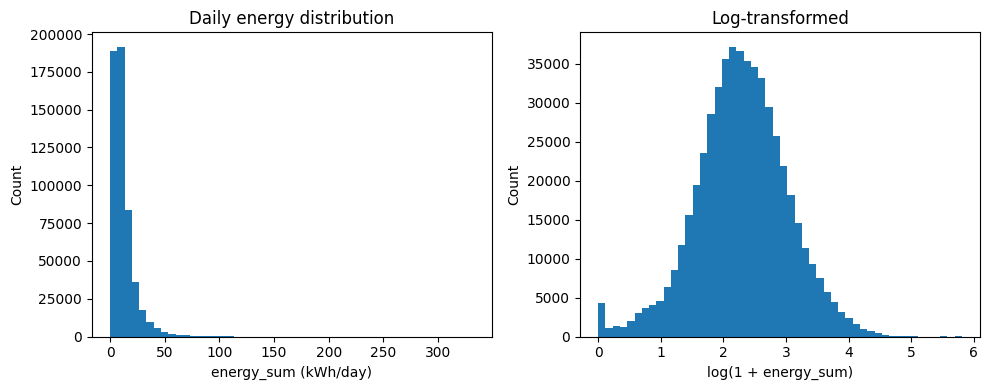

In [13]:
# Histogram of target variable (original and log)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(daily["energy_sum"], bins=50)
plt.xlabel("energy_sum (kWh/day)")
plt.ylabel("Count")
plt.title("Daily energy distribution")

plt.subplot(1, 2, 2)
plt.hist(np.log1p(daily["energy_sum"]), bins=50)
plt.xlabel("log(1 + energy_sum)")
plt.ylabel("Count")
plt.title("Log-transformed")

plt.tight_layout()
plt.show()

### Temperature vs daily usage

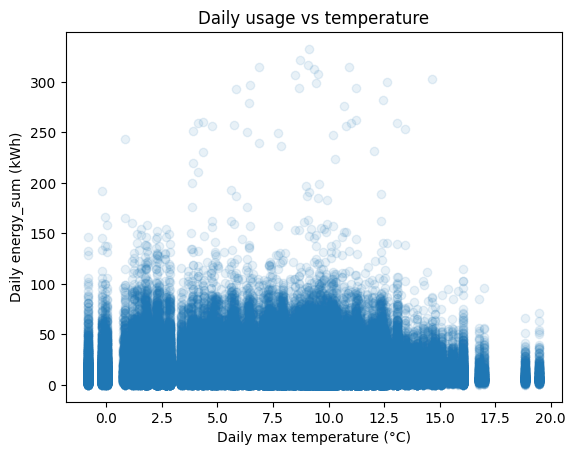

In [14]:
# Temperature vs daily usage
plt.figure()
plt.scatter(daily["temperatureHigh"], daily["energy_sum"], alpha=0.1)
plt.xlabel("Daily max temperature (°C)")
plt.ylabel("Daily energy_sum (kWh)")
plt.title("Daily usage vs temperature")
plt.show()

### Mean usage by month

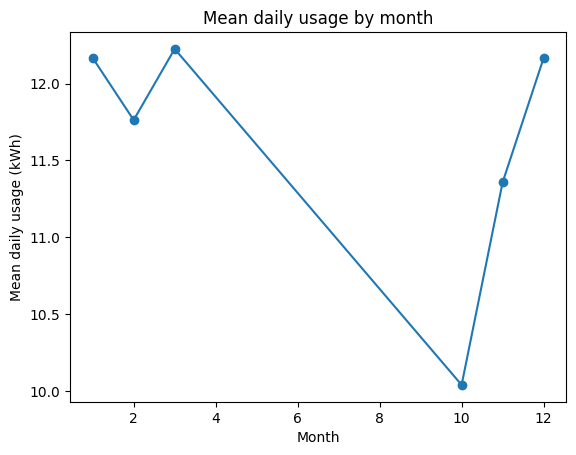

In [15]:
# Mean usage by month
mean_by_month = daily.groupby("month")["energy_sum"].mean()
plt.figure()
plt.plot(mean_by_month.index, mean_by_month.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Mean daily usage (kWh)")
plt.title("Mean daily usage by month")
plt.show()

### Mean usage by day of week

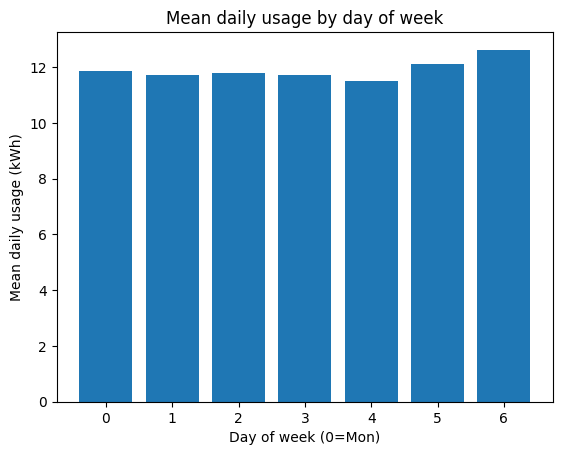

In [16]:
# Mean usage by day of week
mean_by_dow = daily.groupby("day_of_week")["energy_sum"].mean()
plt.figure()
plt.bar(mean_by_dow.index, mean_by_dow.values)
plt.xlabel("Day of week (0=Mon)")
plt.ylabel("Mean daily usage (kWh)")
plt.title("Mean daily usage by day of week")
plt.show()

### Comparison between tarrif types

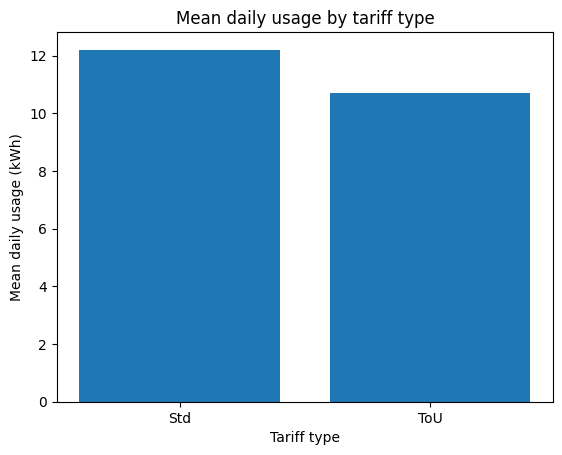

In [17]:
#Comparison between tariff types
tariff_mean = daily.groupby("stdorToU")["energy_sum"].mean()

plt.figure()
plt.bar(tariff_mean.index, tariff_mean.values)
plt.xlabel("Tariff type")
plt.ylabel("Mean daily usage (kWh)")
plt.title("Mean daily usage by tariff type")
plt.show()

### Consumption by ACORN Group

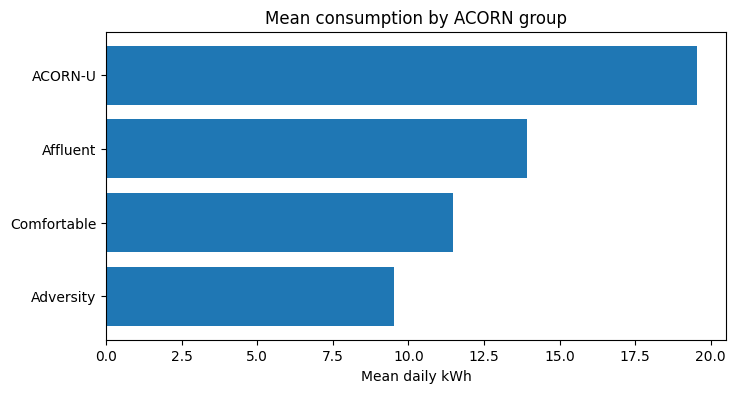

In [18]:
# Mean consumption by ACORN group
acorn_mean = daily.groupby("Acorn_grouped")["energy_sum"].mean()
acorn_mean = acorn_mean.sort_values()

plt.figure(figsize=(8, 4))
plt.barh(acorn_mean.index, acorn_mean.values)
plt.xlabel("Mean daily kWh")
plt.title("Mean consumption by ACORN group")
plt.show()

### Lag Autocorrelation

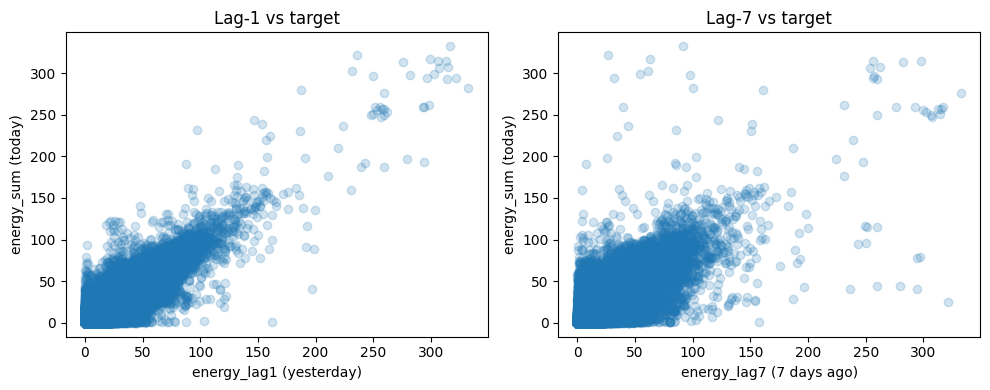

Correlation lag1 vs today: 0.908
Correlation lag7 vs today: 0.844


In [19]:
# Relationship between today and past consumption
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(daily["energy_lag1"], daily["energy_sum"], alpha=0.2)
plt.xlabel("energy_lag1 (yesterday)")
plt.ylabel("energy_sum (today)")
plt.title("Lag-1 vs target")

plt.subplot(1, 2, 2)
plt.scatter(daily["energy_lag7"], daily["energy_sum"], alpha=0.2)
plt.xlabel("energy_lag7 (7 days ago)")
plt.ylabel("energy_sum (today)")
plt.title("Lag-7 vs target")

plt.tight_layout()
plt.show()

r1 = np.corrcoef(daily["energy_lag1"], daily["energy_sum"])[0, 1]
r7 = np.corrcoef(daily["energy_lag7"], daily["energy_sum"])[0, 1]
print("Correlation lag1 vs today:", round(r1, 3))
print("Correlation lag7 vs today:", round(r7, 3))

### PCA and Clustering

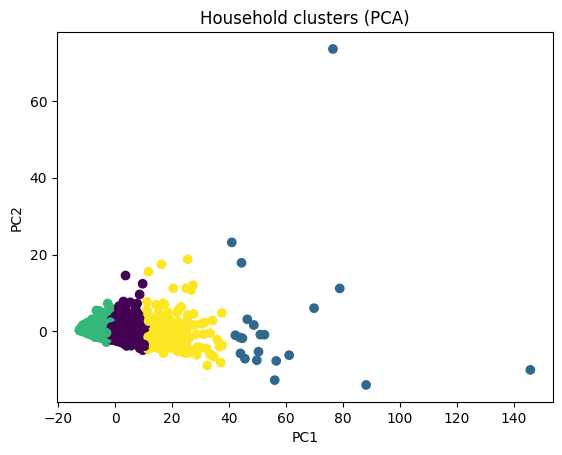

Explained variance ratio: [0.93827732 0.06172268]
         mean_kwh  std_kwh
cluster                   
0           14.76     4.75
1           66.50    26.21
2            6.27     2.11
3           29.88    10.19


In [20]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

household = daily.groupby("LCLid").agg(
    mean_kwh=("energy_sum", "mean"),
    std_kwh=("energy_sum", "std")
)

X = household[["mean_kwh", "std_kwh"]].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=SEED)
household["cluster"] = kmeans.fit_predict(X)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=household["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Household clusters (PCA)")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(household.groupby("cluster")[["mean_kwh", "std_kwh"]].mean().round(2))